In [103]:
import sqlite3
import pandas as pd
import numpy as np
import mne
from mne.preprocessing import ICA
from io import BytesIO
import matplotlib.pyplot as plt

In [104]:
db_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db"

conn = sqlite3.connect(db_path)

table_name = "data_87d03f26-0f33-4e1d-a259-2181ccc29071"

df = pd.read_sql_query(
    f"SELECT * FROM '{table_name}'",
    conn
)

print(df.shape)

(3772, 3)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8251 samples (33.004 s)



/var/folders/33/qg_ry0_n2kb_gsw589xg9z_w0000gn/T/ipykernel_22837/3733942631.py:1: RuntimeWarning: Estimated head radius (11.2 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(set_path, preload=True)
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


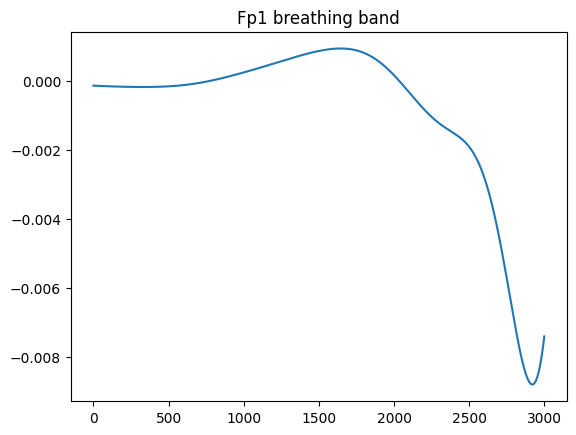

In [105]:

raw = mne.io.read_raw_eeglab(set_path, preload=True)
raw.pick(["Fp1", "Fp2"])

raw.filter(0.1, 40)

eeg_data = raw.get_data()
def bandpass(data, low=0.1, high=0.4, fs=250):

    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")

    return filtfilt(b, a, data)

signal = eeg_data[0]   # Fp1

breath_signal = bandpass(signal)

plt.plot(breath_signal[:3000])

plt.title("Fp1 breathing band")

plt.show()

In [106]:
info = mne.create_info(
    ch_names=["Fp1", "Fp2"],
    sfreq=250,
    ch_types=["eeg", "eeg"]
)

raw = mne.io.RawArray(eeg_data, info)

raw.filter(0.1, 40)

Creating RawArray with float64 data, n_channels=2, n_times=66975
    Range : 0 ... 66974 =      0.000 ...   267.896 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,Not available
Good channels,2 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.10 Hz
Lowpass,40.00 Hz


In [107]:
ica = ICA(n_components=2, random_state=97, max_iter="auto")
ica.fit(raw)

Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.0s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,1 iterations on raw data (66975 samples)
ICA components,2
Available PCA components,2
Channel types,eeg
ICA components marked for exclusion,—


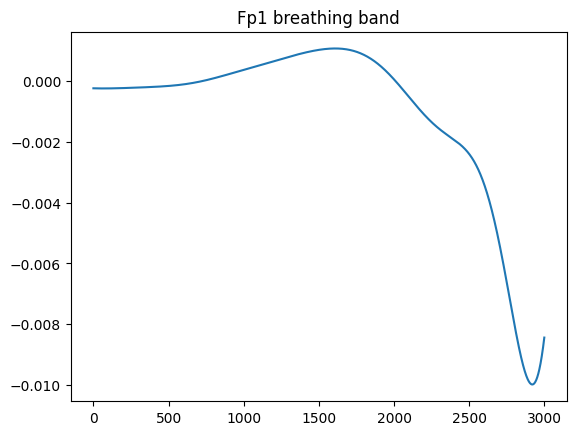

In [119]:
def bandpass(data, low=0.1, high=0.4, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

signal = eeg_data[1]   # Fp2

breath_signal = bandpass(signal)

plt.plot(breath_signal[:3000])
plt.title("Fp1 breathing band")
plt.show()

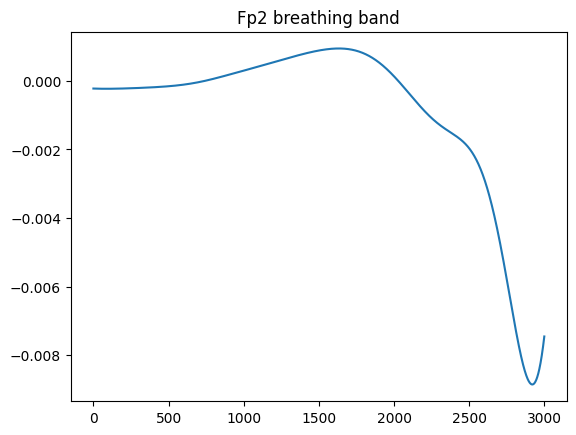

In [109]:
def bandpass(data, low=0.1, high=0.4, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

signal = eeg_data[0]   # 0 = Fp1, 1 = Fp2

breath_signal = bandpass(signal)

plt.plot(breath_signal[:3000])
plt.title("Fp2 breathing band")
plt.show()

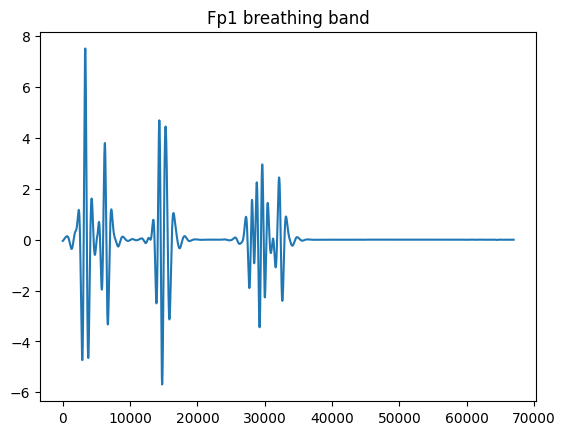

In [110]:
def bandpass(data, low=0.15, high=0.35, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

signal = eeg_data[0]   # 0 = Fp1, 1 = Fp2

breath_signal = bandpass(signal)

breath_z = (breath_signal - np.mean(breath_signal)) / np.std(breath_signal)

plt.plot(breath_z)
plt.title("Fp1 breathing band")
plt.show()

In [111]:
from mne.preprocessing import ICA

raw_ica = raw.copy()

ica = ICA(n_components=2, random_state=97, max_iter="auto")
ica.fit(raw_ica)

sources_raw = ica.get_sources(raw_ica)
sources = sources_raw.get_data()

print("sources shape:", sources.shape)

Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.0s.
sources shape: (2, 66975)


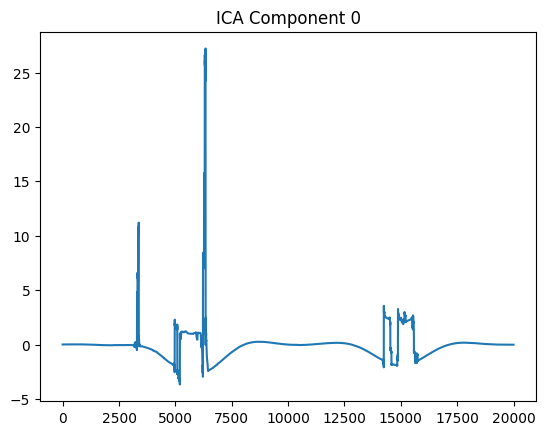

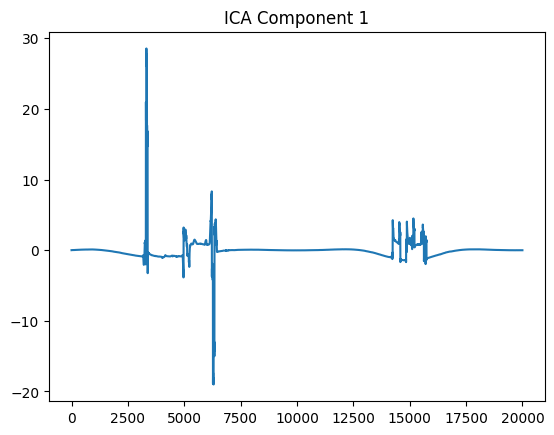

In [112]:
plt.plot(sources[0][:20000])
plt.title("ICA Component 0")
plt.show()

plt.plot(sources[1][:20000])
plt.title("ICA Component 1")
plt.show()

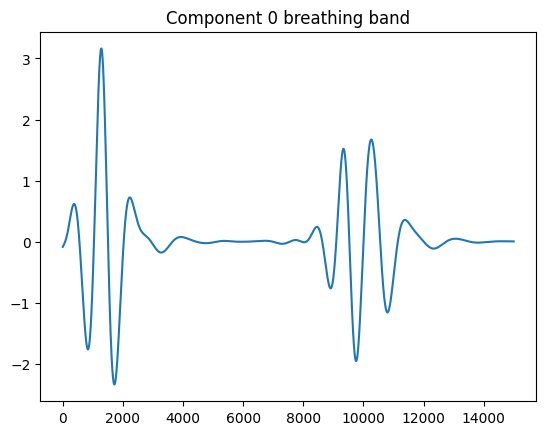

In [113]:
best_comp = 0   # try 0, then try 1

breath_signal = bandpass(sources[best_comp])

plt.plot(breath_signal[5000:20000])
plt.title(f"Component {best_comp} breathing band")
plt.show()

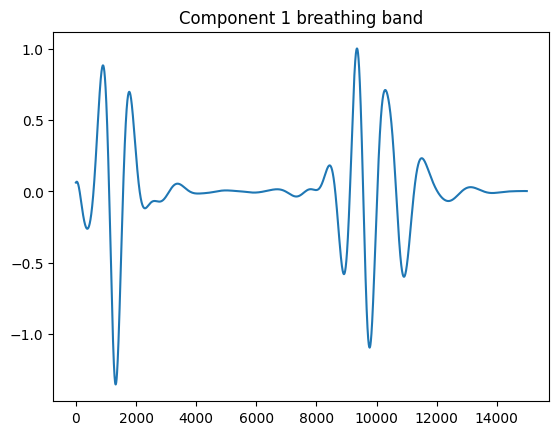

In [114]:
best_comp = 1

breath_signal = bandpass(sources[best_comp])

plt.plot(breath_signal[5000:20000])
plt.title(f"Component {best_comp} breathing band")
plt.show()

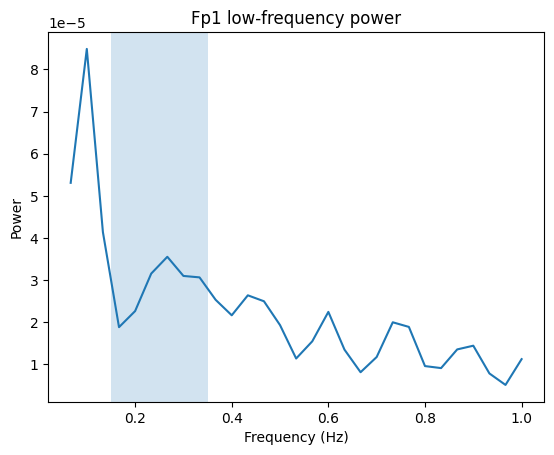

Fp1 peak in breathing band: 0.26666666666666666 Hz


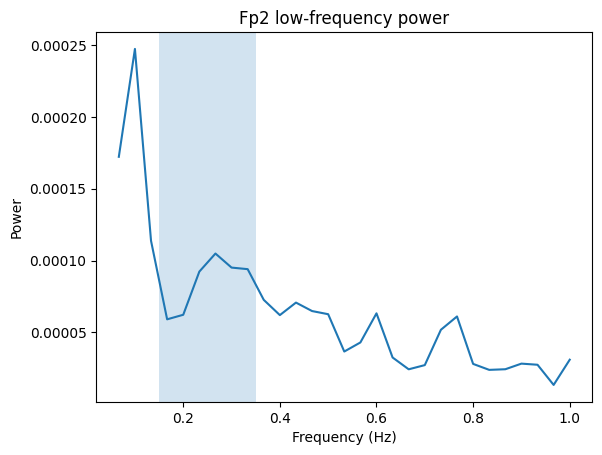

Fp2 peak in breathing band: 0.26666666666666666 Hz


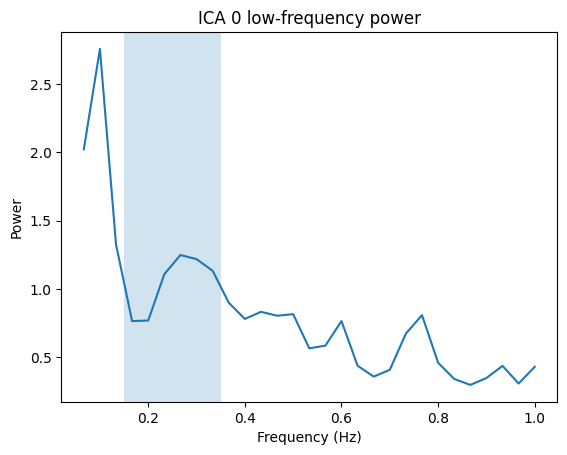

ICA 0 peak in breathing band: 0.26666666666666666 Hz


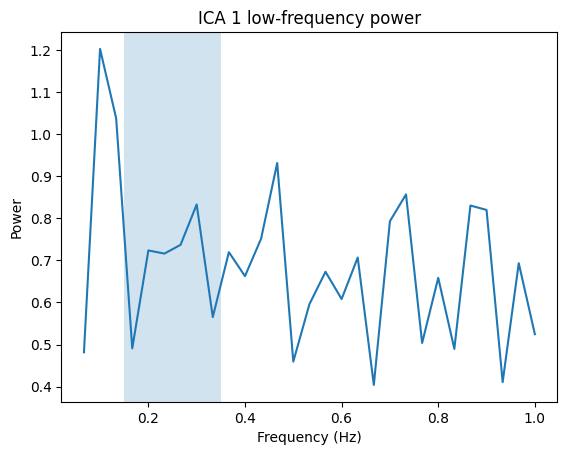

ICA 1 peak in breathing band: 0.3 Hz


In [115]:
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

fs = 250

signals = {
    "Fp1": eeg_data[0],
    "Fp2": eeg_data[1],
    "ICA 0": sources[0],
    "ICA 1": sources[1],
}

for name, sig in signals.items():
    f, pxx = welch(sig, fs=fs, nperseg=fs*30)

    mask = (f >= 0.05) & (f <= 1.0)

    plt.figure()
    plt.plot(f[mask], pxx[mask])
    plt.axvspan(0.15, 0.35, alpha=0.2)
    plt.title(f"{name} low-frequency power")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.show()

    breath_mask = (f >= 0.15) & (f <= 0.35)
    peak_freq = f[breath_mask][np.argmax(pxx[breath_mask])]

    print(name, "peak in breathing band:", peak_freq, "Hz")

In [116]:
raw_clean = raw.copy()

# remove very large spikes
raw_clean = raw_clean.copy().crop(tmin=5)

# stronger high-pass to reduce drift
raw_clean.filter(0.05, 5)

eeg_clean = raw_clean.get_data()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.05 - 5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.05
- Lower transition bandwidth: 0.05 Hz (-6 dB cutoff frequency: 0.03 Hz)
- Upper passband edge: 5.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Filter length: 16501 samples (66.004 s)



[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


In [117]:
signal = eeg_clean[0]

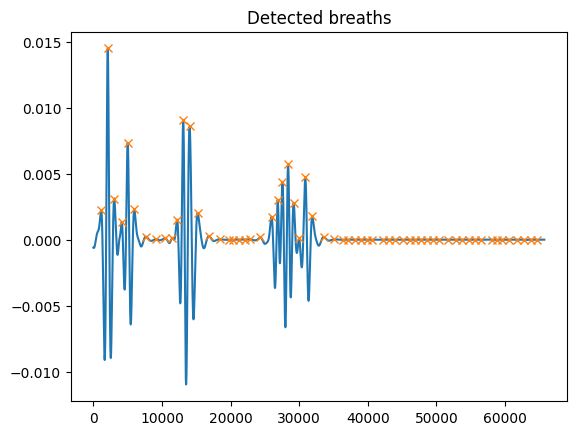

Estimated respiration rate: 14.149866869532142 breaths/min


In [118]:
from scipy.signal import find_peaks

breath_signal = bandpass(signal, low=0.15, high=0.35)

peaks, _ = find_peaks(
    breath_signal,
    distance=fs*2
)

plt.plot(breath_signal)
plt.plot(peaks, breath_signal[peaks], "x")
plt.title("Detected breaths")
plt.show()

duration_sec = len(breath_signal) / fs
breaths_per_min = len(peaks) / duration_sec * 60

print("Estimated respiration rate:", breaths_per_min, "breaths/min")

Shape: (23793, 7)
Labels:
3
TH    5944
T1    5923
EL    3632
EA    3632
SF    2408
HR     537
BI     537
TL     312
SA     269
SR     269
B%     160
BV     160
RB       1
MY       1
MX       1
GZ       1
GY       1
GX       1
AZ       1
AY       1
AX       1
MZ       1
Name: count, dtype: int64
HR shape: (537, 7)
BI shape: (537, 7)


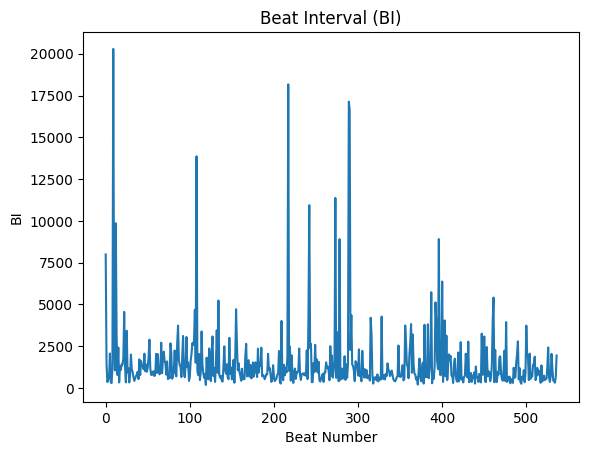

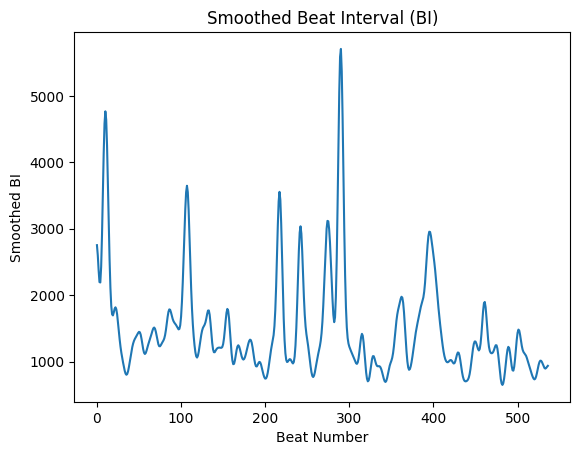

Mean BI: 1490.9310986964617
Std BI: 2027.6008584192962


In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

ppg_csv_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686.csv"

ppg = pd.read_csv(
    ppg_csv_path,
    engine="python",
    header=None,
    on_bad_lines="skip"
)

print("Shape:", ppg.shape)
print("Labels:")
print(ppg[3].value_counts().head(30))

hr = ppg[ppg[3] == "HR"].copy()
bi = ppg[ppg[3] == "BI"].copy()

print("HR shape:", hr.shape)
print("BI shape:", bi.shape)

bi_vals = bi[6].astype(float).values

plt.plot(bi_vals)
plt.title("Beat Interval (BI)")
plt.xlabel("Beat Number")
plt.ylabel("BI")
plt.show()

bi_smooth = gaussian_filter1d(bi_vals, sigma=3)

plt.plot(bi_smooth)
plt.title("Smoothed Beat Interval (BI)")
plt.xlabel("Beat Number")
plt.ylabel("Smoothed BI")
plt.show()

print("Mean BI:", np.mean(bi_vals))
print("Std BI:", np.std(bi_vals))

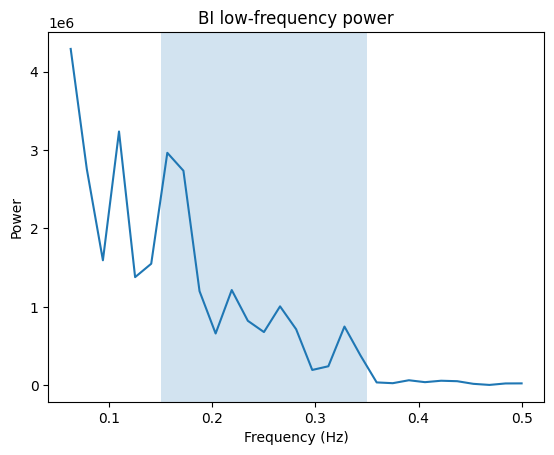

Peak respiration-related frequency: 0.15625 Hz
Estimated breaths/min: 9.375


In [131]:
from scipy.signal import welch

# approximate BI sampling rate
fs_bi = 4

f, pxx = welch(
    bi_smooth,
    fs=fs_bi,
    nperseg=min(256, len(bi_smooth))
)

mask = (f >= 0.05) & (f <= 0.5)

plt.plot(f[mask], pxx[mask])
plt.axvspan(0.15, 0.35, alpha=0.2)
plt.title("BI low-frequency power")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

breath_mask = (f >= 0.15) & (f <= 0.35)

peak_freq = f[breath_mask][np.argmax(pxx[breath_mask])]

print("Peak respiration-related frequency:", peak_freq, "Hz")
print("Estimated breaths/min:", peak_freq * 60)

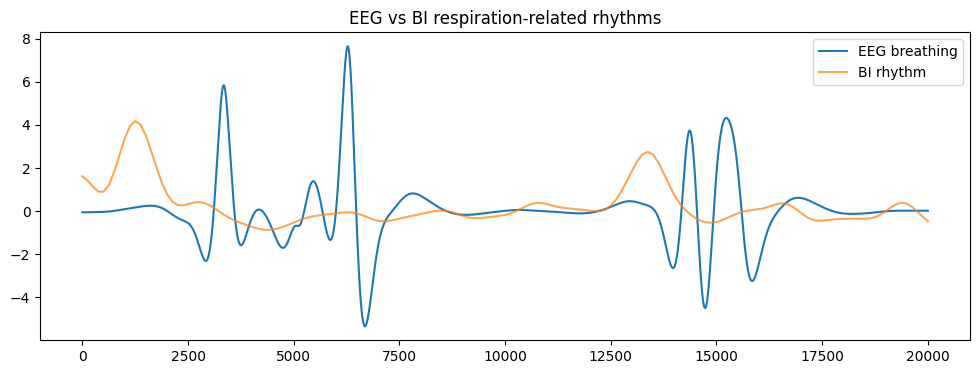

In [132]:
eeg_breath = breath_signal

eeg_breath = (eeg_breath - np.mean(eeg_breath)) / np.std(eeg_breath)
bi_norm = (bi_smooth - np.mean(bi_smooth)) / np.std(bi_smooth)

# stretch BI to EEG length
bi_interp = np.interp(
    np.linspace(0, len(bi_norm)-1, len(eeg_breath)),
    np.arange(len(bi_norm)),
    bi_norm
)

plt.figure(figsize=(12,4))
plt.plot(eeg_breath[:20000], label="EEG breathing")
plt.plot(bi_interp[:20000], label="BI rhythm", alpha=0.7)
plt.legend()
plt.title("EEG vs BI respiration-related rhythms")
plt.show()

In [133]:
from scipy.stats import pearsonr

# make sure both are normalized
eeg_breath = (breath_signal - np.mean(breath_signal)) / np.std(breath_signal)
bi_norm = (bi_smooth - np.mean(bi_smooth)) / np.std(bi_smooth)

# stretch BI to EEG length
bi_interp = np.interp(
    np.linspace(0, len(bi_norm)-1, len(eeg_breath)),
    np.arange(len(bi_norm)),
    bi_norm
)

# compare same length
r, p = pearsonr(eeg_breath, bi_interp)

print("EEG-BI correlation:", r)
print("p-value:", p)

EEG-BI correlation: 0.007020045394522073
p-value: 0.06925645431125127


Best lag samples: -4750
Best lag seconds: -19.0
Best correlation: 0.10184186263185756


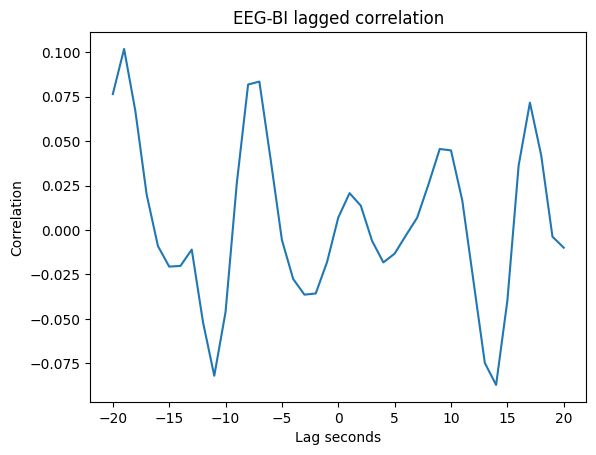

In [134]:
lags = np.arange(-5000, 5001, 250)
corrs = []

for lag in lags:
    if lag < 0:
        r = np.corrcoef(eeg_breath[-lag:], bi_interp[:lag])[0, 1]
    elif lag > 0:
        r = np.corrcoef(eeg_breath[:-lag], bi_interp[lag:])[0, 1]
    else:
        r = np.corrcoef(eeg_breath, bi_interp)[0, 1]
    corrs.append(r)

best_i = np.argmax(np.abs(corrs))

print("Best lag samples:", lags[best_i])
print("Best lag seconds:", lags[best_i] / fs)
print("Best correlation:", corrs[best_i])

plt.plot(lags / fs, corrs)
plt.title("EEG-BI lagged correlation")
plt.xlabel("Lag seconds")
plt.ylabel("Correlation")
plt.show()